# Stacked LSTM Blood Glucose Pipeline for Colab

This notebook is standalone: it defines the XML parser, feature engineering, windowing, scaling, model, training, testing, metrics, and export steps in one place. It does not import project modules.

Expected OhioT1DM layout can be any of these common Colab or Kaggle shapes:

- `/content/drive/MyDrive/OhioT1DM/2018/train/*.xml`
- `/content/drive/MyDrive/<folder>/OhioT1DM/2018/train/*.xml`
- `/kaggle/input/<dataset>/OhioT1DM/2018/train/*.xml`
- `/kaggle/input/<dataset>/2018/train/*.xml`
- a manually configured path in `DATA_DIR` below.

In [1]:
!unzip -P "...@@@!!==/\/\/\/\~~~~~BGLP-1804-BGLP~~~~~/\/\/\/\==!!@@@..." /content/OhioT1DM.zip -d /content/dataset

BASE_DIR = '/content/dataset/OhioT1DM'

Archive:  /content/OhioT1DM.zip
   creating: /content/dataset/OhioT1DM/
   creating: /content/dataset/OhioT1DM/2018/
   creating: /content/dataset/OhioT1DM/2018/test/
  inflating: /content/dataset/OhioT1DM/2018/test/559-ws-testing.xml  
  inflating: /content/dataset/OhioT1DM/2018/test/563-ws-testing.xml  
  inflating: /content/dataset/OhioT1DM/2018/test/570-ws-testing.xml  
  inflating: /content/dataset/OhioT1DM/2018/test/575-ws-testing.xml  
  inflating: /content/dataset/OhioT1DM/2018/test/588-ws-testing.xml  
  inflating: /content/dataset/OhioT1DM/2018/test/591-ws-testing.xml  
   creating: /content/dataset/OhioT1DM/2018/train/
  inflating: /content/dataset/OhioT1DM/2018/train/559-ws-training.xml  
  inflating: /content/dataset/OhioT1DM/2018/train/563-ws-training.xml  
  inflating: /content/dataset/OhioT1DM/2018/train/570-ws-training.xml  
  inflating: /content/dataset/OhioT1DM/2018/train/575-ws-training.xml  
  inflating: /content/dataset/OhioT1DM/2018/train/588-ws-training.xml  
  

In [2]:
# Optional install cell. Uncomment only if your Colab image is missing a package.
# !pip install -q tensorflow scikit-learn pandas matplotlib

import os
import random
import sys
import warnings
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow.keras.callbacks import BackupAndRestore, CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.losses import Poisson
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# -----------------------------
# Configuration
# -----------------------------

DATA_DIR =  "/content/dataset/OhioT1DM"
USE_GOOGLE_DRIVE_ON_COLAB = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/stacked_lstm_outputs12345"

def running_on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def setup_output_dir():
    if running_on_colab() and USE_GOOGLE_DRIVE_ON_COLAB:
        from google.colab import drive
        drive.mount("/content/drive")
        output_dir = Path(DRIVE_OUTPUT_DIR)
    else:
        output_dir = Path("stacked_lstm_outputs")
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir

OUTPUT_DIR = setup_output_dir()

CFG = {
    "cohorts": {
        "2018": [559, 563, 570, 575, 588, 591],
        "2020": [540, 544, 552, 567, 584, 596],
    },
    "train_suffix": "-ws-training.xml",
    "test_suffix": "-ws-testing.xml",
    "resample_freq": "5min",
    "lookback_minutes": 30,
    "forecast_minutes": 30,
    "freq_minutes": 5,
    "rolling_insulin_window": 36,
    "excluded_features": ["acceleration", "basis_steps", "basis_air_temperature", "basis_heart_rate"],
    "resume_training": True,
    "model": {
        "units": 128,
        "dropout": 0.2,
        "dense_units": [512, 128],
        "learning_rate": 0.01,
        "epochs": 1000,
        "batch_size": 256,
        "validation_split": 0.1,
        "early_stopping_patience": 128,
        "reduce_lr_patience": 32,
        "reduce_lr_factor": 0.5,
        "min_lr": 1e-6,
    },
}

print("Outputs will be saved to:", OUTPUT_DIR)

Mounted at /content/drive
Outputs will be saved to: /content/drive/MyDrive/stacked_lstm_outputs12345


In [4]:
# -----------------------------
# XML parsing and feature engineering
# -----------------------------

TS_FORMATS = ("%d-%m-%Y %H:%M:%S", "%Y-%m-%d %H:%M:%S", "%m/%d/%Y %H:%M:%S", "%d-%m-%Y %H:%M")
HIGH_MISSING_FEATURES = {"acceleration", "basis_steps", "basis_air_temperature", "basis_heart_rate"}
LOCF_FEATURES = ("basal", "basis_gsr", "finger_stick")
ZERO_IMPUTE_FEATURES = ("bolus", "meal", "exercise", "basis_skin_temperature", "basis_sleep")
POINT_VALUE_ATTRS = {
    "bolus": "dose",
    "meal": "carbs",
    "finger_stick": "value",
    "basal": "value",
    "basis_gsr": "value",
    "basis_skin_temperature": "value",
}

def parse_ts(ts_str):
    if isinstance(ts_str, datetime):
        return ts_str
    if ts_str is None or pd.isna(ts_str):
        return None
    for fmt in TS_FORMATS:
        try:
            return datetime.strptime(str(ts_str).strip(), fmt)
        except ValueError:
            pass
    return None

def parse_feature_dataframe(xml_path, feature):
    empty = pd.DataFrame(columns=["value"], index=pd.DatetimeIndex([]))
    if not Path(xml_path).exists():
        return empty
    root = ET.parse(xml_path).getroot()
    container = root.find(feature)
    if container is None:
        return empty
    records = []
    for el in container:
        if feature == "bolus":
            ts = el.get("ts_begin") or el.get("ts")
            value = el.get("dose")
        elif feature == "temp_basal":
            ts = el.get("ts_begin") or el.get("ts")
            value = el.get("value")
        elif feature == "exercise":
            ts = el.get("ts")
            value = el.get("duration")
        else:
            ts = el.get("ts")
            value = el.get("value")
        records.append({"ts": ts, "value": value})
    if not records:
        return empty
    df = pd.DataFrame(records).dropna(subset=["ts", "value"])
    df["ts"] = df["ts"].apply(parse_ts)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna().set_index("ts").sort_index()
    return df[~df.index.duplicated(keep="first")]

def align_glucose_to_grid(glucose_df, resample_freq):
    if glucose_df.empty:
        return glucose_df
    grouped = glucose_df.groupby(level=0).mean().sort_index()
    freq_delta = pd.Timedelta(resample_freq)
    elapsed = grouped.index - grouped.index.min()
    has_single_phase = pd.Index(elapsed % freq_delta).nunique() <= 1
    if has_single_phase:
        grid = pd.date_range(grouped.index.min(), grouped.index.max(), freq=resample_freq)
        return grouped.reindex(grid)
    rounded = grouped.copy()
    rounded.index = rounded.index.round(resample_freq)
    rounded = rounded.groupby(level=0).mean().sort_index()
    grid = pd.date_range(rounded.index.min(), rounded.index.max(), freq=resample_freq)
    return rounded.reindex(grid)

def parse_events(xml_path, feature):
    columns = ["ts", "ts_begin", "ts_end", "value"]
    root = ET.parse(xml_path).getroot()
    container = root.find(feature)
    if container is None:
        return pd.DataFrame(columns=columns)
    records = []
    for el in container:
        ts = el.get("ts")
        ts_begin = el.get("ts_begin") or el.get("tbegin")
        ts_end = el.get("ts_end") or el.get("tend")
        if feature == "basis_sleep":
            value = 1
        elif feature == "exercise":
            ts_begin = ts_begin or ts
            duration = pd.to_numeric(el.get("duration"), errors="coerce")
            begin = parse_ts(ts_begin) if ts_begin else None
            if begin is not None and not pd.isna(duration):
                ts_end = begin + pd.Timedelta(minutes=float(duration))
            value = el.get("intensity") or 1
        elif feature == "temp_basal":
            value = el.get("value") or el.get("dose") or el.get("rate")
        else:
            value = el.get(POINT_VALUE_ATTRS.get(feature, "value"))
        records.append({"ts": ts, "ts_begin": ts_begin, "ts_end": ts_end, "value": value})
    df = pd.DataFrame(records, columns=columns)
    if df.empty:
        return df
    for col in ["ts", "ts_begin", "ts_end"]:
        df[col] = df[col].apply(parse_ts)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df.dropna(subset=["value"])

def empty_aligned(glucose_index, column_name):
    return pd.DataFrame({column_name: np.nan}, index=glucose_index)

def align_to_glucose_index(df, glucose_index, column_name, agg="mean"):
    if df.empty:
        return empty_aligned(glucose_index, column_name)
    aligned = df.copy()
    nearest_pos = glucose_index.get_indexer(aligned.index, method="nearest")
    aligned = aligned[nearest_pos >= 0]
    nearest_pos = nearest_pos[nearest_pos >= 0]
    if aligned.empty:
        return empty_aligned(glucose_index, column_name)
    aligned.index = glucose_index.take(nearest_pos)
    aligned = aligned.rename(columns={"value": column_name})
    if agg == "sum":
        aligned = aligned.groupby(level=0).sum()
    elif agg == "count":
        aligned = aligned.groupby(level=0).count()
    else:
        aligned = aligned.groupby(level=0).mean()
    return aligned.reindex(glucose_index)

def align_point_feature(xml_path, feature, glucose_index, column_name=None, agg="mean"):
    column_name = column_name or feature
    events = parse_events(xml_path, feature)
    if events.empty:
        return empty_aligned(glucose_index, column_name)
    ts = events["ts"].where(events["ts"].notna(), events["ts_begin"])
    valid = ts.notna()
    if not valid.any():
        return empty_aligned(glucose_index, column_name)
    df = events.loc[valid, ["value"]].copy()
    df.index = pd.DatetimeIndex(ts.loc[valid])
    return align_to_glucose_index(df, glucose_index, column_name, agg=agg)

def align_interval_feature(xml_path, feature, glucose_index, column_name=None, default_value=1.0):
    column_name = column_name or feature
    events = parse_events(xml_path, feature)
    out = pd.Series(0.0, index=glucose_index, name=column_name)
    counts = pd.Series(0.0, index=glucose_index)
    if events.empty:
        return out.to_frame()
    for _, row in events.iterrows():
        begin, end = row["ts_begin"], row["ts_end"]
        if pd.isna(begin) or pd.isna(end):
            continue
        if end < begin:
            begin, end = end, begin
        value = row["value"] if not pd.isna(row["value"]) else default_value
        mask = (glucose_index >= begin) & (glucose_index <= end)
        out.loc[mask] += float(value)
        counts.loc[mask] += 1
    covered = counts > 0
    out.loc[covered] = out.loc[covered] / counts.loc[covered]
    return out.to_frame()

def apply_temp_basal_override(master):
    if "temp_basal" not in master.columns:
        return master
    master = master.copy()
    master["temp_basal"] = master["temp_basal"].fillna(0)
    temp_override = master["temp_basal"].ne(0)
    master.loc[temp_override, "basal"] = master.loc[temp_override, "temp_basal"]
    if {"bolus", "basal"}.issubset(master.columns):
        master["total_insulin"] = master["bolus"] + master["basal"] * (5 / 60)
    return master.drop(columns=["temp_basal"])

def build_patient_master(xml_path, cfg):
    xml_path = Path(xml_path)
    gl = parse_feature_dataframe(xml_path, "glucose_level")
    if gl.empty:
        return pd.DataFrame()
    gl = align_glucose_to_grid(gl, cfg["resample_freq"])
    gl["glucose_level"] = gl["value"]
    gl = gl.drop(columns="value")
    idx = gl.index

    master = gl.join([
        align_point_feature(xml_path, "bolus", idx, agg="sum"),
        align_point_feature(xml_path, "bolus", idx, "bolus_count", agg="count"),
        align_point_feature(xml_path, "meal", idx, agg="sum"),
        align_point_feature(xml_path, "basal", idx),
        align_interval_feature(xml_path, "temp_basal", idx),
        align_interval_feature(xml_path, "exercise", idx),
        align_point_feature(xml_path, "basis_gsr", idx),
        align_point_feature(xml_path, "finger_stick", idx),
        align_point_feature(xml_path, "basis_skin_temperature", idx),
        align_interval_feature(xml_path, "basis_sleep", idx),
    ], how="left")

    zero_cols = [c for c in ZERO_IMPUTE_FEATURES if c in master.columns]
    locf_cols = [c for c in LOCF_FEATURES if c in master.columns]
    master[zero_cols] = master[zero_cols].fillna(0)
    master[locf_cols] = master[locf_cols].ffill().fillna(0)
    master = apply_temp_basal_override(master)
    master["bolus_count"] = master["bolus_count"].fillna(0)
    master["total_insulin"] = master["bolus"] + master["basal"] * (5 / 60)
    master["insulin_count"] = master["bolus_count"]
    master["insulin_3h_std"] = master["total_insulin"].rolling(cfg["rolling_insulin_window"], min_periods=1).std().fillna(0)
    master["daily_exercise"] = master["exercise"].gt(0).groupby(master.index.date).transform("max").astype(int)
    master = master.drop(columns=["bolus_count"])
    master = master.drop(columns=[c for c in HIGH_MISSING_FEATURES if c in master.columns])
    return master

def find_xml_files(base_dir, cfg):
    base_dir = Path(base_dir)
    train_files, test_files = {}, {}
    for year, patient_ids in cfg["cohorts"].items():
        for pid in patient_ids:
            key = f"{pid}_{year}"
            train_path = base_dir / year / "train" / f"{pid}{cfg['train_suffix']}"
            test_path = base_dir / year / "test" / f"{pid}{cfg['test_suffix']}"
            if train_path.exists():
                train_files[key] = train_path
            else:
                print("Missing train file:", train_path)
            if test_path.exists():
                test_files[key] = test_path
            else:
                print("Missing test file:", test_path)
    return train_files, test_files

def build_all_masters(file_dict, cfg):
    masters = {}
    for key, path in sorted(file_dict.items()):
        df = build_patient_master(path, cfg)
        masters[key] = df
        print(f"{key:10s} rows={len(df):6d} cols={list(df.columns)}")
    return masters

In [5]:
# -----------------------------
# Windowing, scaling, and metrics
# -----------------------------

TARGET_COL = "glucose_level"
class DatasetScaler:
    def __init__(self):
        self.scaler_glucose = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
        self.fitted = False

    def fit(self, X_train_3d, y_train):
        self.scaler_glucose.fit(X_train_3d[:, :, 0].reshape(-1, 1))
        self.scaler_y.fit(y_train)
        self.fitted = True
        return self

    def transform_3d(self, *arrays):
        if not self.fitted:
            raise RuntimeError("DatasetScaler must be fitted before transform.")
        out = []
        for X in arrays:
            Xs = X.copy()
            n, steps, _ = Xs.shape
            Xs[:, :, 0] = self.scaler_glucose.transform(Xs[:, :, 0].reshape(-1, 1)).reshape(n, steps)
            out.append(Xs.astype(np.float32))
        return out

    def transform_y(self, *arrays):
        if not self.fitted:
            raise RuntimeError("DatasetScaler must be fitted before transform.")
        return [self.scaler_y.transform(y).astype(np.float32) for y in arrays]

    def inverse_transform_y(self, y_scaled):
        if not self.fitted:
            raise RuntimeError("DatasetScaler must be fitted before inverse transform.")
        return self.scaler_y.inverse_transform(y_scaled)



def create_multistep_dataset(df, target_col, lookback_steps, forecast_steps, feature_cols, freq_minutes):
    feature_data = df[feature_cols].values.astype(np.float32)
    target_data = df[target_col].values.astype(np.float32)
    expected_delta = pd.Timedelta(minutes=freq_minutes) if isinstance(df.index, pd.DatetimeIndex) else None
    X, y = [], []
    for i in range(len(df) - lookback_steps - forecast_steps + 1):
        if expected_delta is not None:
            idx = df.index[i : i + lookback_steps + forecast_steps]
            if not idx.to_series().diff().iloc[1:].eq(expected_delta).all():
                continue
        x_window = feature_data[i : i + lookback_steps, :]
        y_window = target_data[i + lookback_steps : i + lookback_steps + forecast_steps]
        if np.isnan(x_window).any() or np.isnan(y_window).any():
            continue
        X.append(x_window)
        y.append(y_window)
    if not X:
        return np.empty((0, lookback_steps, len(feature_cols)), dtype=np.float32), np.empty((0, forecast_steps), dtype=np.float32)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def build_global_dataset(patient_dfs, lookback_steps, forecast_steps, target_col, feature_cols, freq_minutes):
    all_X, all_y = [], []
    min_len = lookback_steps + forecast_steps
    for pid, df in patient_dfs.items():
        if df.empty or len(df) < min_len:
            print(f"Skipping {pid}: only {len(df)} rows")
            continue
        Xp, yp = create_multistep_dataset(df, target_col, lookback_steps, forecast_steps, feature_cols, freq_minutes)
        if len(Xp) == 0:
            print(f"Skipping {pid}: no complete windows")
            continue
        all_X.append(Xp)
        all_y.append(yp)
        print(f"{pid:10s} windows={len(Xp):6d}")
    if not all_X:
        raise ValueError("No valid patient windows were built.")
    return np.concatenate(all_X, axis=0), np.concatenate(all_y, axis=0)

def prepare_raw_datasets(train_masters, test_masters, cfg):
    """Build the single glucose_level-only dataset using raw glucose values."""
    lb_steps = cfg["lookback_minutes"] // cfg["freq_minutes"]
    fc_steps = cfg["forecast_minutes"] // cfg["freq_minutes"]

    feature_cols = [TARGET_COL]
    tag = "glucose_level only (raw)"
    print("\nBuilding dataset:", tag)

    X_train, y_train = build_global_dataset(
        train_masters, lb_steps, fc_steps, TARGET_COL, feature_cols, cfg["freq_minutes"]
    )
    X_test, y_test = build_global_dataset(
        test_masters,  lb_steps, fc_steps, TARGET_COL, feature_cols, cfg["freq_minutes"]
    )

    scaler = DatasetScaler().fit(X_train, y_train)
    (X_train_s,) = scaler.transform_3d(X_train)
    (X_test_s,)  = scaler.transform_3d(X_test)
    (y_train_s,) = scaler.transform_y(y_train)
    (y_test_s,)  = scaler.transform_y(y_test)

    print(f"{tag}: X_train={X_train_s.shape}, X_test={X_test_s.shape}, features={len(feature_cols)}")
    return [{
        "tag": tag,
        "feature_cols": feature_cols,
        "X_train_3d": X_train_s,
        "X_test_3d":  X_test_s,
        "y_train":    y_train,
        "y_test":     y_test,
        "y_train_s":  y_train_s,
        "y_test_s":   y_test_s,
        "scaler":     scaler,
    }]

In [6]:
# -----------------------------
# Build masters and datasets from XML
# -----------------------------

train_files, test_files = find_xml_files(DATA_DIR, CFG)
print(f"Discovered {len(train_files)} train files and {len(test_files)} test files")

train_masters = build_all_masters(train_files, CFG)
test_masters = build_all_masters(test_files, CFG)

if not train_masters or not test_masters:
    raise RuntimeError("No training/testing data loaded. Check DATA_DIR and dataset layout.")

# Optional cache for inspection or reuse in later Colab/Kaggle cells.
processed_dir = OUTPUT_DIR / "processed"
(processed_dir / "train").mkdir(parents=True, exist_ok=True)
(processed_dir / "test").mkdir(parents=True, exist_ok=True)
for key, df in train_masters.items():
    if not df.empty:
        df.to_csv(processed_dir / "train" / f"{key}_train_master.csv", index_label="ts")
for key, df in test_masters.items():
    if not df.empty:
        df.to_csv(processed_dir / "test" / f"{key}_test_master.csv", index_label="ts")

variants = prepare_raw_datasets(train_masters, test_masters, CFG)

Discovered 12 train files and 12 test files
540_2020   rows= 13109 cols=['glucose_level', 'bolus', 'meal', 'basal', 'exercise', 'basis_gsr', 'finger_stick', 'basis_skin_temperature', 'basis_sleep', 'total_insulin', 'insulin_count', 'insulin_3h_std', 'daily_exercise']
544_2020   rows= 12672 cols=['glucose_level', 'bolus', 'meal', 'basal', 'exercise', 'basis_gsr', 'finger_stick', 'basis_skin_temperature', 'basis_sleep', 'total_insulin', 'insulin_count', 'insulin_3h_std', 'daily_exercise']
552_2020   rows= 11098 cols=['glucose_level', 'bolus', 'meal', 'basal', 'exercise', 'basis_gsr', 'finger_stick', 'basis_skin_temperature', 'basis_sleep', 'total_insulin', 'insulin_count', 'insulin_3h_std', 'daily_exercise']
559_2018   rows= 12081 cols=['glucose_level', 'bolus', 'meal', 'basal', 'exercise', 'basis_gsr', 'finger_stick', 'basis_skin_temperature', 'basis_sleep', 'total_insulin', 'insulin_count', 'insulin_3h_std', 'daily_exercise']
563_2018   rows= 13097 cols=['glucose_level', 'bolus', 'meal

In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel())))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true.ravel(), y_pred.ravel()))

def r2(y_true, y_pred):
    return float(r2_score(y_true.ravel(), y_pred.ravel()))

def mard(y_true, y_pred):
    y_true_flat = y_true.ravel()
    y_pred_flat = y_pred.ravel()
    mask = y_true_flat != 0
    return float(np.mean(np.abs(y_true_flat[mask] - y_pred_flat[mask]) / np.abs(y_true_flat[mask])) * 100)

def compute_all_metrics(y_true, y_pred):
    return {"rmse": rmse(y_true, y_pred), "mae": mae(y_true, y_pred), "r2": r2(y_true, y_pred), "mard": mard(y_true, y_pred)}

def all_horizons(y):
    """Return all fc_steps forecast targets (shape: N x fc_steps)."""
    return y.astype(np.float32)

def inverse_all_horizons(target_scaler, y_all_scaled):
    """Inverse-transform all forecast steps (shape: N x fc_steps → mg/dL)."""
    return target_scaler.inverse_transform_y(y_all_scaled)

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Stacked LSTM model and training pipeline
#
# RESUMING AFTER A COLAB SESSION ENDS / RESTARTS
# ──────────────────────────────────────────────
# Training state is saved to Google Drive (OUTPUT_DIR) at every epoch via:
#   • model.keras          – full model weights + architecture
#   • training_backup/     – Keras BackupAndRestore snapshot (exact epoch state)
#   • epoch_log.csv        – one row per completed epoch (loss, val_loss, lr)
#
# When the session restarts, just re-run ALL cells from top to bottom.
# The setup_output_dir() call re-mounts Drive, build_all_masters() re-parses
# the XML, prepare_raw_datasets() rebuilds windows, and then this cell:
#   1. Reads epoch_log.csv to find initial_epoch (epochs already done).
#   2. Loads model.keras so weights are restored.
#   3. Calls model.fit(..., initial_epoch=initial_epoch) to continue from where
#      it left off without retraining any epoch twice.
#
# Set CFG["resume_training"] = False to force a fresh run.
# ─────────────────────────────────────────────────────────────────────────────

def build_stacked_lstm(input_shape, cfg, fc_steps=1):
    mc = cfg["model"]
    model = Sequential([
        Input(shape=input_shape),
        LSTM(mc["units"], return_sequences=True),
        Dropout(mc["dropout"]),
        LSTM(mc["units"]),
        Dense(mc["dense_units"][0], activation="relu"),
        Dense(mc["dense_units"][1], activation="relu"),
        Dense(fc_steps, activation="exponential"),  # predict all 6 forecast steps
    ])
    model.compile(optimizer=Adam(mc["learning_rate"]), loss=Poisson(name="negative_log_likelihood"))
    return model


def make_callbacks(checkpoint_path=None, backup_dir=None, epoch_log_path=None):
    """
    BackupAndRestore  – saves a full training snapshot each epoch so Colab
                        can resume mid-training after a crash or disconnect.
    ModelCheckpoint   – saves model.keras after every epoch (not best-only)
                        so the latest weights survive a session restart.
    CSVLogger         – appends one row per epoch to epoch_log.csv;
                        used to determine initial_epoch on resume.
    """
    mc = CFG["model"]
    callbacks = []
    if backup_dir is not None:
        callbacks.append(
            BackupAndRestore(backup_dir=backup_dir, save_freq="epoch", delete_checkpoint=False)
        )
    callbacks.extend([
        EarlyStopping(
            monitor="val_loss",
            patience=mc["early_stopping_patience"],
            restore_best_weights=True,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=mc["reduce_lr_factor"],
            patience=mc["reduce_lr_patience"],
            min_lr=mc["min_lr"],
        ),
    ])
    if checkpoint_path is not None:
        # save_best_only=False ensures the latest checkpoint is always on disk
        callbacks.append(ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=False))
    if epoch_log_path is not None:
        # append=True so re-runs after a restart add to the existing log
        callbacks.append(CSVLogger(epoch_log_path, append=True))
    return callbacks


def train_and_test_stacked_lstm(variant, cfg, output_dir):
    tag_slug = variant["tag"].lower().replace(" ", "_").replace("+", "plus")
    model_dir      = Path(output_dir) / "checkpoints" / tag_slug
    model_dir.mkdir(parents=True, exist_ok=True)
    model_path     = model_dir / "model.keras"
    backup_dir     = model_dir / "training_backup"
    epoch_log_path = model_dir / "epoch_log.csv"
    fc_steps = cfg["forecast_minutes"] // cfg["freq_minutes"]

    X_train        = variant["X_train_3d"]
    X_test         = variant["X_test_3d"]
    y_train_all_s  = all_horizons(variant["y_train_s"])   # shape: N x fc_steps
    total_epochs   = cfg["model"]["epochs"]

    # ── Determine how many epochs have already been completed ─────────────────
    initial_epoch = 0
    if cfg.get("resume_training", True) and epoch_log_path.exists():
        try:
            log_df = pd.read_csv(epoch_log_path)
            initial_epoch = len(log_df)
            print(f"[Resume] Found {initial_epoch} completed epoch(s) in {epoch_log_path}")
        except Exception as exc:
            print(f"[Resume] Could not read epoch log ({exc}); starting from epoch 0.")
            initial_epoch = 0

    # ── Load existing weights or build a fresh model ──────────────────────────
    if cfg.get("resume_training", True) and model_path.exists():
        print(f"[Resume] Loading checkpoint: {model_path}")
        model = load_model(model_path)
    else:
        print("[Train] Building new model.")
        model = build_stacked_lstm((X_train.shape[1], X_train.shape[2]), cfg, fc_steps=fc_steps)

    # ── Train (or skip if already finished) ───────────────────────────────────
    if initial_epoch >= total_epochs:
        print(f"[Skip] Already at {initial_epoch}/{total_epochs} epochs — evaluating saved model.")
        history = None
    else:
        remaining = total_epochs - initial_epoch
        print(f"[Train] Running epochs {initial_epoch + 1}–{total_epochs} ({remaining} remaining).")
        history = model.fit(
            X_train,
            y_train_all_s,   # all 6 forecast steps
            initial_epoch=initial_epoch,
            epochs=total_epochs,
            batch_size=cfg["model"]["batch_size"],
            validation_split=cfg["model"]["validation_split"],
            callbacks=make_callbacks(str(model_path), str(backup_dir), str(epoch_log_path)),
            verbose=1,
        )

    model.save(model_path)

    # ── Evaluate on test set (all 6 forecast steps = full 30-min horizon) ────
    preds_s = model.predict(X_test, verbose=0)          # shape: N x fc_steps (scaled)
    preds   = inverse_all_horizons(variant["scaler"], preds_s)  # shape: N x fc_steps (mg/dL)
    actual  = all_horizons(variant["y_test"])           # shape: N x fc_steps (mg/dL)
    test_metrics = compute_all_metrics(actual, preds)   # flattened over all steps

    # Also compute per-step metrics for detailed inspection
    per_step_metrics = {}
    for step_idx in range(fc_steps):
        step_min = (step_idx + 1) * cfg["freq_minutes"]
        per_step_metrics[f"+{step_min}min"] = compute_all_metrics(
            actual[:, step_idx:step_idx+1], preds[:, step_idx:step_idx+1]
        )

    # Save predictions for all steps: columns actual_t+5min … actual_t+30min
    col_names = {
        f"actual_t+{(s+1)*cfg['freq_minutes']}min":    actual[:, s]
        for s in range(fc_steps)
    }
    col_names.update({
        f"predicted_t+{(s+1)*cfg['freq_minutes']}min": preds[:, s]
        for s in range(fc_steps)
    })
    pred_df = pd.DataFrame(col_names)
    pred_path = Path(output_dir) / f"predictions_{tag_slug}.csv"
    pred_df.to_csv(pred_path, index=False)

    history_df = pd.DataFrame(history.history) if history is not None else pd.DataFrame()
    history_path = Path(output_dir) / f"history_last_fit_{tag_slug}.csv"
    history_df.to_csv(history_path, index=False)

    return model, history, preds, test_metrics, per_step_metrics, model_path, pred_path, history_path, epoch_log_path


# ── Run ────────────────────────────────────────────────────────────────────────
results = []
predictions_by_tag = {}

for variant in variants:
    print("\n" + "=" * 80)
    print("Training STACKED_LSTM:", variant["tag"])
    (
        model, history, preds, test_metrics, per_step_metrics,
        model_path, pred_path, history_path, epoch_log_path
    ) = train_and_test_stacked_lstm(variant, CFG, OUTPUT_DIR)
    predictions_by_tag[variant["tag"]] = preds
    record = {
        "model":    "STACKED_LSTM",
        "features": variant["tag"],
        **{f"test_{k}": round(v, 4) for k, v in test_metrics.items()},
        "model_path":        str(model_path),
        "predictions_path":  str(pred_path),
        "history_path":      str(history_path),
        "epoch_log_path":    str(epoch_log_path),
    }
    print("Result:", record)
    print("Per-step metrics (all 6 forecast horizons):")
    for horizon_tag, m in per_step_metrics.items():
        print(f"  {horizon_tag}: RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  MARD={m['mard']:.4f}%  R²={m['r2']:.4f}")
    results.append(record)
    tf.keras.backend.clear_session()

results_df = pd.DataFrame(results).sort_values("test_rmse").reset_index(drop=True)
results_path = OUTPUT_DIR / "stacked_lstm_results.csv"
results_df.to_csv(results_path, index=False)
results_df


Training STACKED_LSTM: glucose_level only (raw)
[Train] Building new model.
[Train] Running epochs 1–1000 (1000 remaining).
Epoch 1/1000
458/458 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.6658 - val_loss: 0.6319 - learning_rate: 0.0100
Epoch 2/1000
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.6590 - val_loss: 0.6318 - learning_rate: 0.0100
Epoch 3/1000
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6589 - val_loss: 0.6316 - learning_rate: 0.0100
Epoch 4/1000
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6588 - val_loss: 0.6316 - learning_rate: 0.0100
Epoch 5/1000
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.6588 - val_loss: 0.6314 - learning_rate: 0.0100
Epoch 6/1000
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6588 - val_loss: 0.6312 - learning_rate: 0.0100
Epoch 7/1000
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.6587 - val_loss: 0.6313 - learning_rate: 0.0100
Epoch 8/1000
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.6587 - val_loss: 0.631

,model,features,test_rmse,test_mae,test_r2,test_mard,model_path,predictions_path,history_path,epoch_log_path
0,STACKED_LSTM,glucose_level only (raw),13.0509,8.265,0.9531,5.5363,/content/drive/MyDrive/stacked_lstm_outputs123...,/content/drive/MyDrive/stacked_lstm_outputs123...,/content/drive/MyDrive/stacked_lstm_outputs123...,/content/drive/MyDrive/stacked_lstm_outputs123...


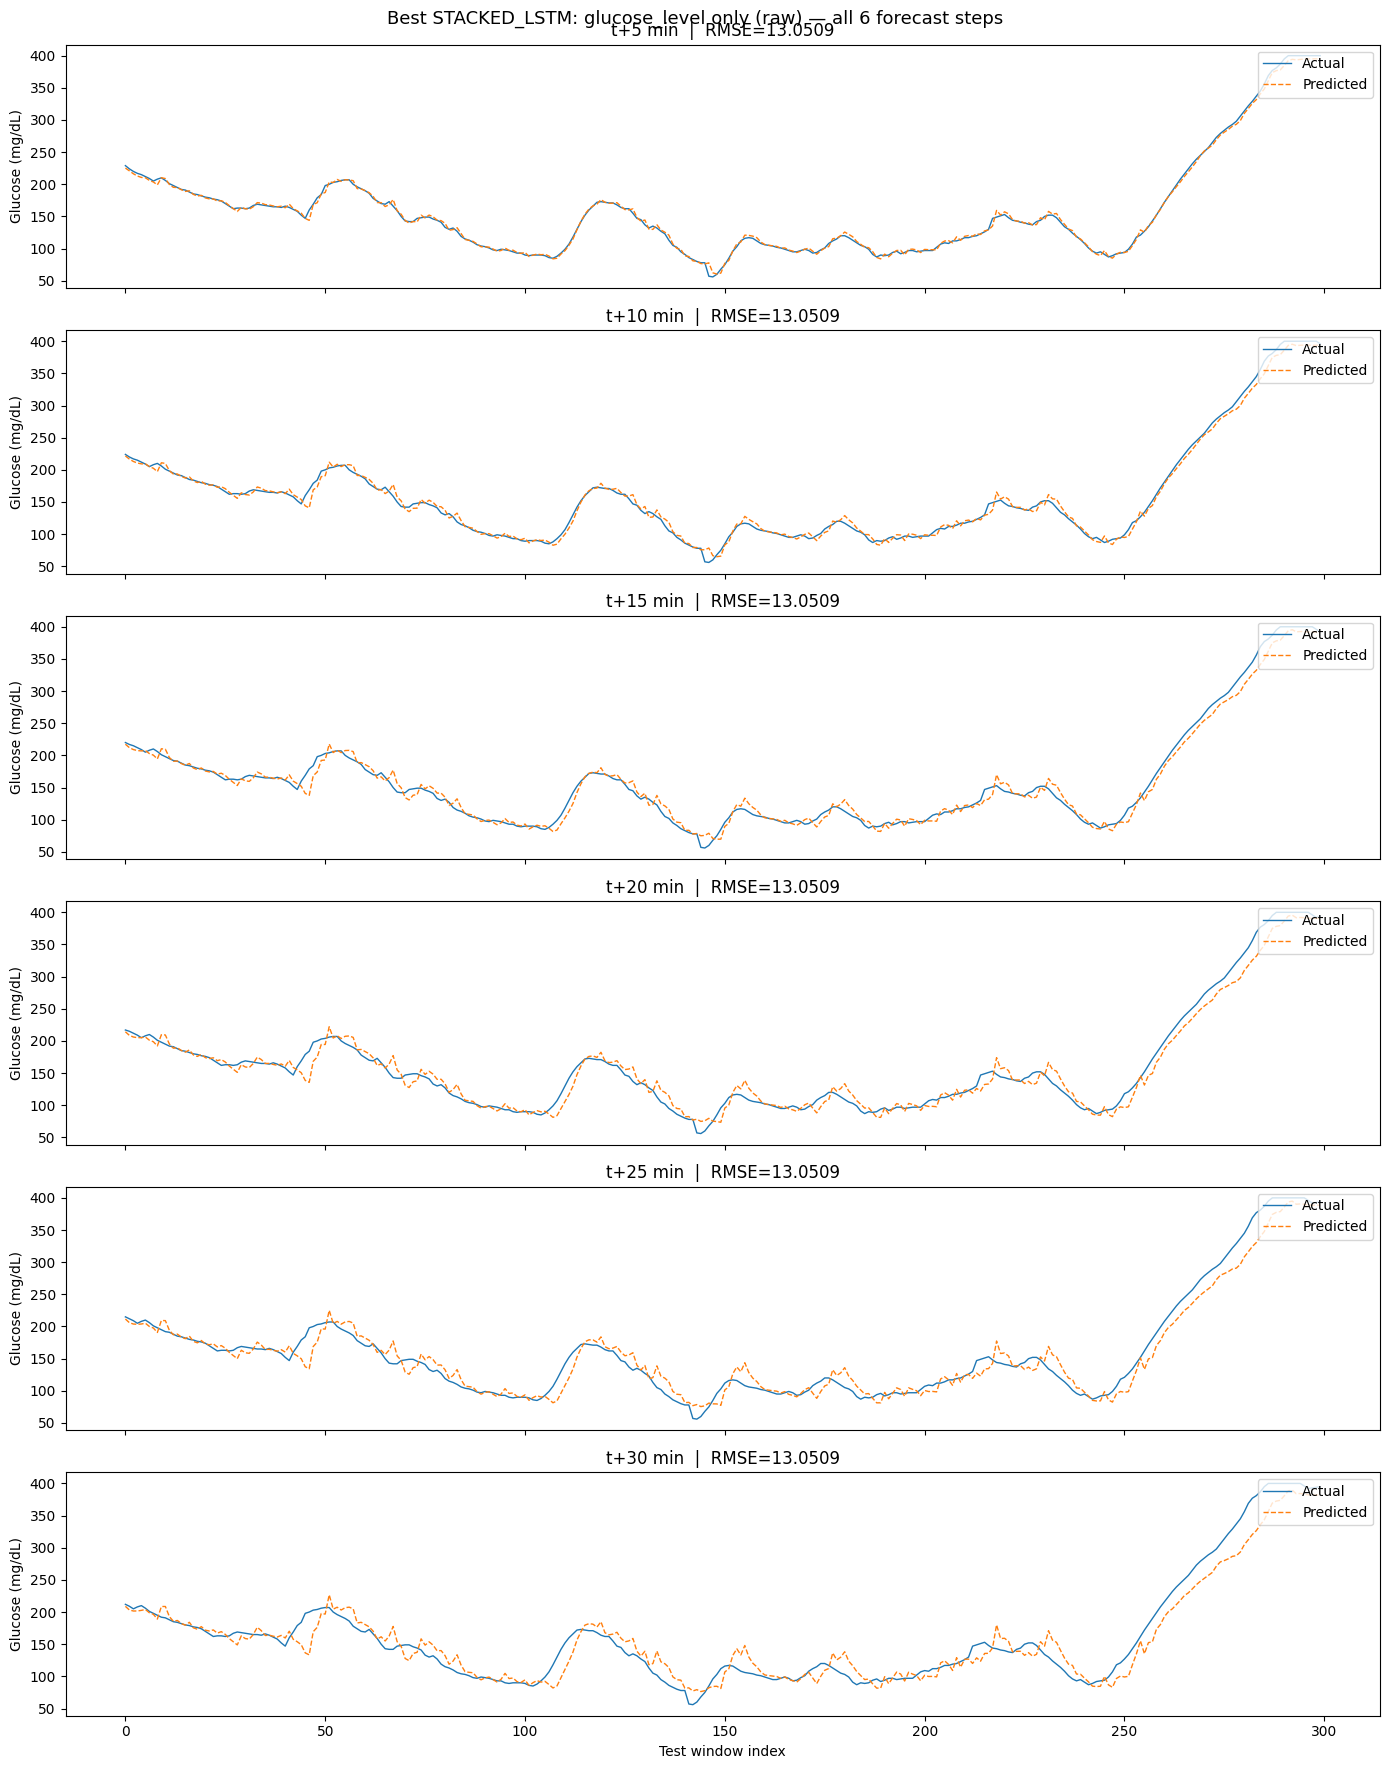

Saved results: /content/drive/MyDrive/stacked_lstm_outputs12345/stacked_lstm_results.csv
Saved plot: /content/drive/MyDrive/stacked_lstm_outputs12345/best_stacked_lstm_predictions.png
Best model path: /content/drive/MyDrive/stacked_lstm_outputs12345/checkpoints/glucose_level_only_(raw)/model.keras


In [10]:
# -----------------------------
# Quick visual check for the best run (all 6 forecast horizons)
# -----------------------------

import matplotlib.pyplot as plt

best         = results_df.iloc[0]
best_variant = next(v for v in variants if v["tag"] == best["features"])
best_preds   = predictions_by_tag[best["features"]]   # shape: N x fc_steps (mg/dL)
fc_steps     = CFG["forecast_minutes"] // CFG["freq_minutes"]
best_actual  = all_horizons(best_variant["y_test"])   # shape: N x fc_steps (mg/dL)

n = min(300, len(best_actual))

fig, axes = plt.subplots(fc_steps, 1, figsize=(14, 3 * fc_steps), sharex=True)
if fc_steps == 1:
    axes = [axes]

for step_idx, ax in enumerate(axes):
    step_min = (step_idx + 1) * CFG["freq_minutes"]
    ax.plot(best_actual[:n, step_idx], label="Actual", linewidth=1.0)
    ax.plot(best_preds[:n, step_idx],  label="Predicted", linewidth=1.0, linestyle="--")
    ax.set_title(f"t+{step_min} min  |  RMSE={best[f'test_rmse']:.4f}")
    ax.set_ylabel("Glucose (mg/dL)")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Test window index")
fig.suptitle(f"Best STACKED_LSTM: {best['features']} — all 6 forecast steps", fontsize=13)
plt.tight_layout()
plot_path = OUTPUT_DIR / "best_stacked_lstm_predictions.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print("Saved results:", results_path)
print("Saved plot:", plot_path)
print("Best model path:", best["model_path"])

In [11]:
# -----------------------------
# Print evaluation metrics — all 6 forecast horizons (30-min prediction)
# -----------------------------

variant  = variants[0]   # glucose_level only (raw)
fc_steps = CFG["forecast_minutes"] // CFG["freq_minutes"]   # = 6

preds_s = model.predict(variant["X_test_3d"], verbose=0)            # N x fc_steps (scaled)
preds   = inverse_all_horizons(variant["scaler"], preds_s)           # N x fc_steps (mg/dL)
actual  = all_horizons(variant["y_test"])                            # N x fc_steps (mg/dL)

# ── Overall metrics (flattened across all 6 steps) ────────────────────────────
overall = compute_all_metrics(actual, preds)

print("=" * 50)
print(f"  Tag    : {variant['tag']}")
print(f"  Horizon: all 6 steps (t+5 min … t+30 min)")
print("  --- Overall (all steps flattened) ---")
print(f"    MAE   : {overall['mae']:.4f} mg/dL")
print(f"    MARD  : {overall['mard']:.4f} %")
print(f"    R²    : {overall['r2']:.4f}")
print(f"    RMSE  : {overall['rmse']:.4f} mg/dL")
print()
print("  --- Per-step breakdown ---")
for step_idx in range(fc_steps):
    step_min = (step_idx + 1) * CFG["freq_minutes"]
    m = compute_all_metrics(actual[:, step_idx:step_idx+1], preds[:, step_idx:step_idx+1])
    print(f"  t+{step_min:2d}min  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  MARD={m['mard']:.4f}%  R²={m['r2']:.4f}")
print("=" * 50)

  Tag    : glucose_level only (raw)
  Horizon: all 6 steps (t+5 min … t+30 min)
  --- Overall (all steps flattened) ---
    MAE   : 8.2650 mg/dL
    MARD  : 5.5363 %
    R²    : 0.9531
    RMSE  : 13.0509 mg/dL

  --- Per-step breakdown ---
  t+ 5min  RMSE=4.4901  MAE=2.9197  MARD=1.8992%  R²=0.9944
  t+10min  RMSE=7.6616  MAE=5.0030  MARD=3.3573%  R²=0.9838
  t+15min  RMSE=10.7589  MAE=7.2095  MARD=4.8307%  R²=0.9681
  t+20min  RMSE=13.6891  MAE=9.3818  MARD=6.2824%  R²=0.9484
  t+25min  RMSE=16.4768  MAE=11.4925  MARD=7.7148%  R²=0.9253
  t+30min  RMSE=19.1952  MAE=13.5834  MARD=9.1334%  R²=0.8988


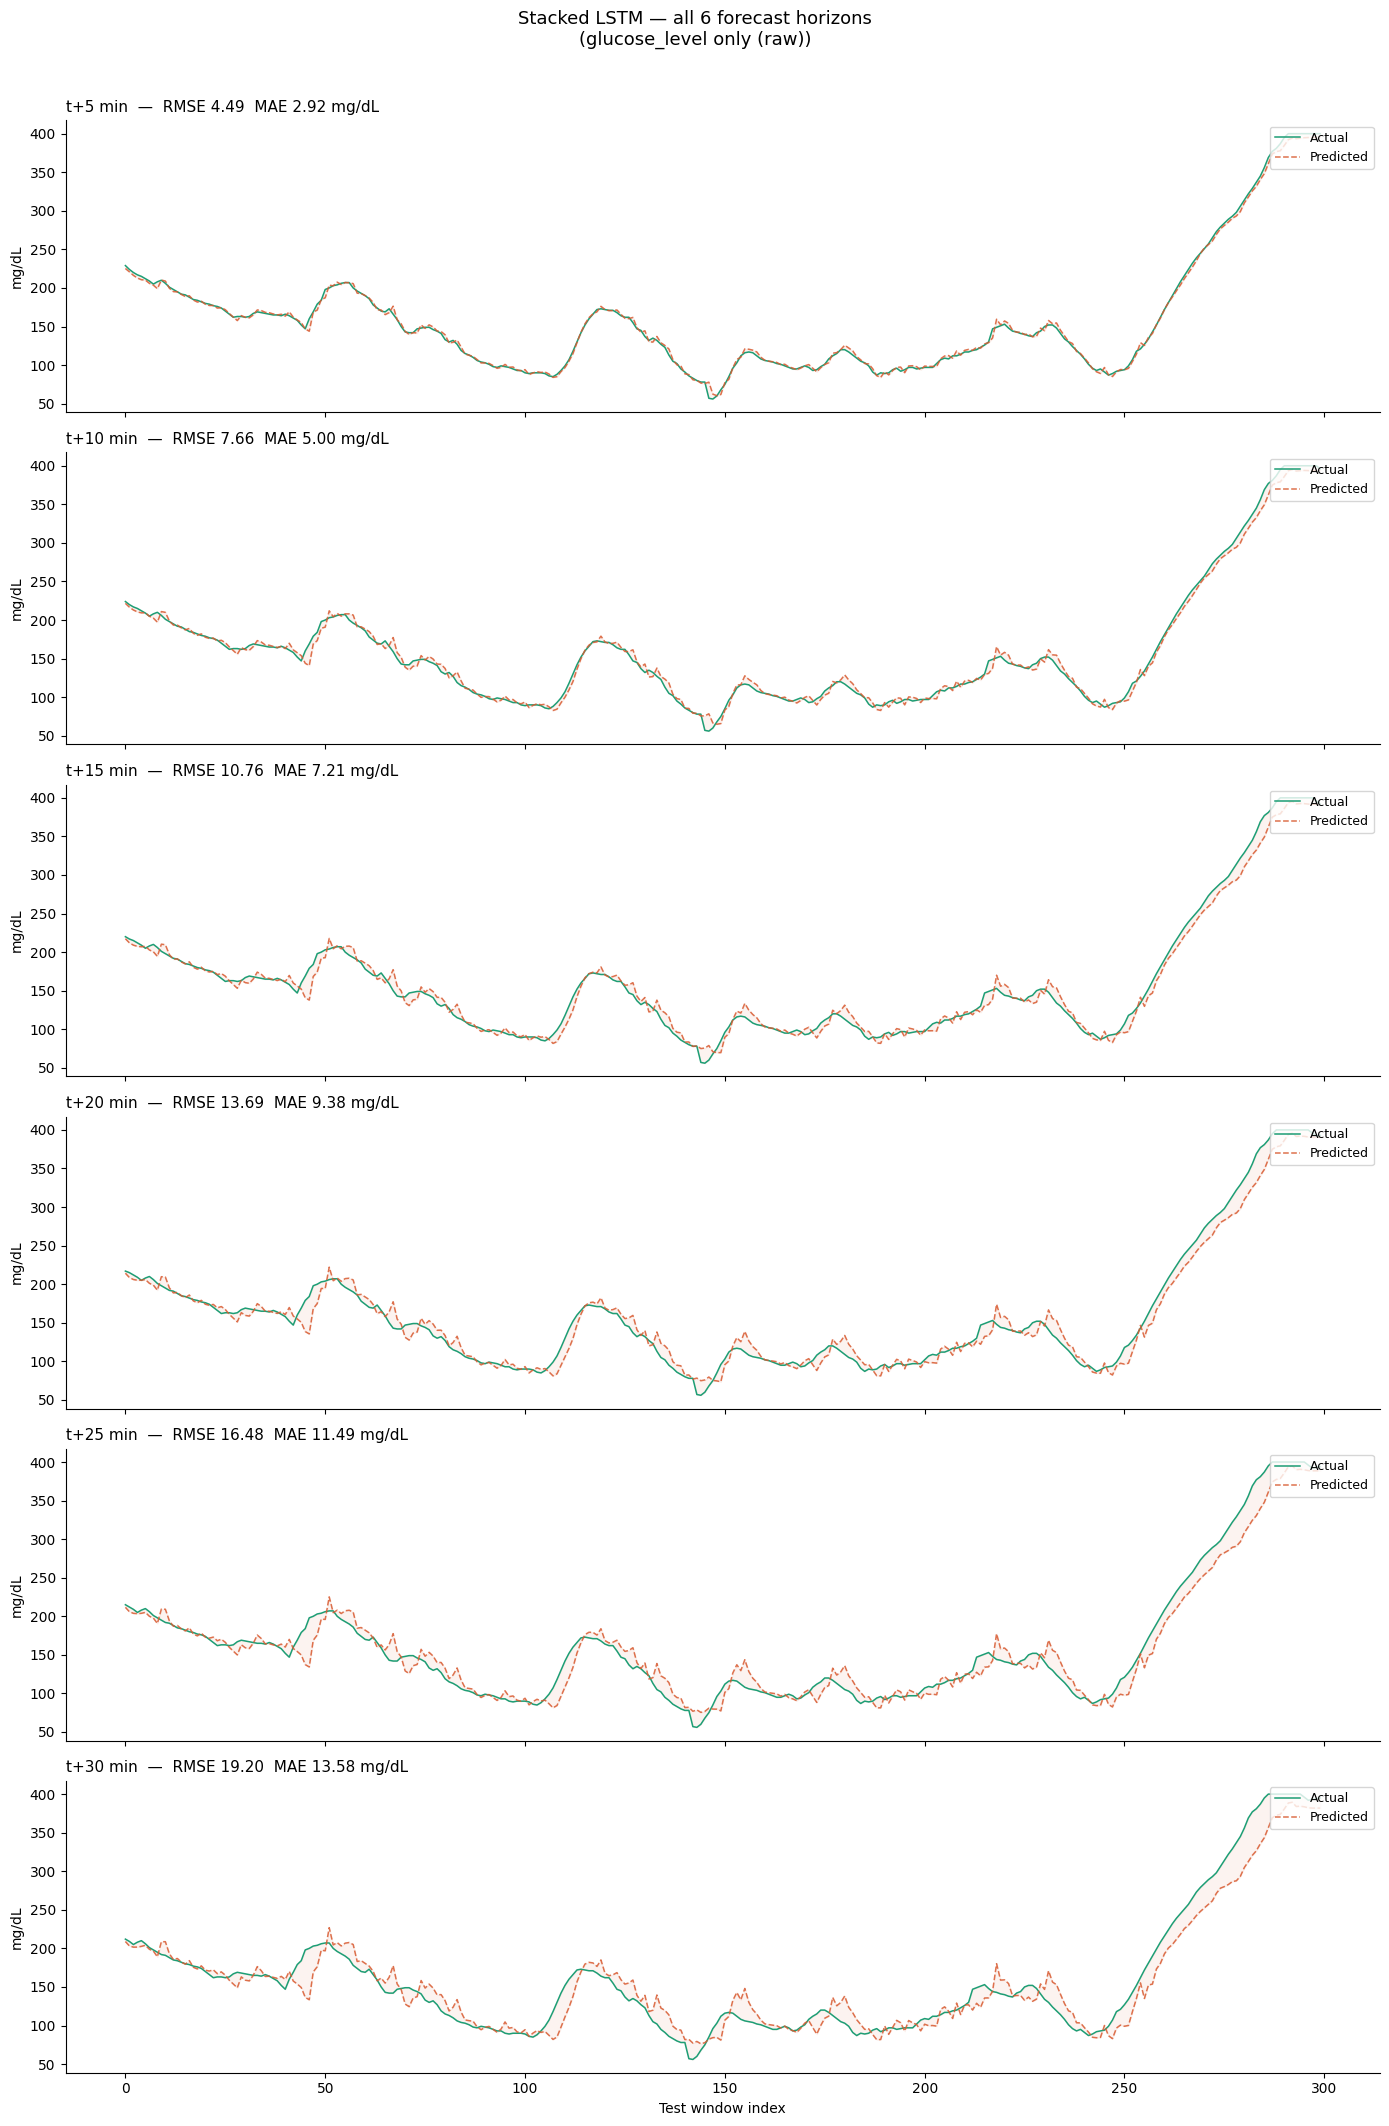

Saved: /content/drive/MyDrive/stacked_lstm_outputs12345/forecast_all_horizons.png


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

FREQ = CFG["freq_minutes"]
FORECAST_STEPS = CFG["forecast_minutes"] // FREQ  # 6
N_PLOT = 300

tag_slug = variants[0]["tag"].lower().replace(" ", "_").replace("+", "plus")
pred_path = OUTPUT_DIR / f"predictions_{tag_slug}.csv"
df = pd.read_csv(pred_path)

fig, axes = plt.subplots(FORECAST_STEPS, 1,
                          figsize=(14, 3.5 * FORECAST_STEPS),
                          sharex=True)

for step, ax in enumerate(axes, start=1):
    mins = step * FREQ
    actual = df[f"actual_t+{mins}min"].values
    preds  = df[f"predicted_t+{mins}min"].values
    n      = min(N_PLOT, len(actual))

    rmse_val = float(np.sqrt(mean_squared_error(actual, preds)))
    mae_val  = float(mean_absolute_error(actual, preds))

    ax.plot(actual[:n], label="Actual",    color="#1d9e75", linewidth=1.1)
    ax.plot(preds[:n],  label="Predicted", color="#d85a30",
            linewidth=1.1, linestyle="--", alpha=0.85)
    ax.fill_between(range(n), actual[:n], preds[:n],
                    alpha=0.07, color="#d85a30")

    ax.set_title(f"t+{mins} min  —  RMSE {rmse_val:.2f}  MAE {mae_val:.2f} mg/dL",
                 fontsize=11, loc="left")
    ax.set_ylabel("mg/dL")
    ax.legend(loc="upper right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Test window index")
fig.suptitle(f"Stacked LSTM — all 6 forecast horizons\n"
             f"({variants[0]['tag']})", fontsize=13, y=1.01)
plt.tight_layout()
save_path = OUTPUT_DIR / "forecast_all_horizons.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", save_path)

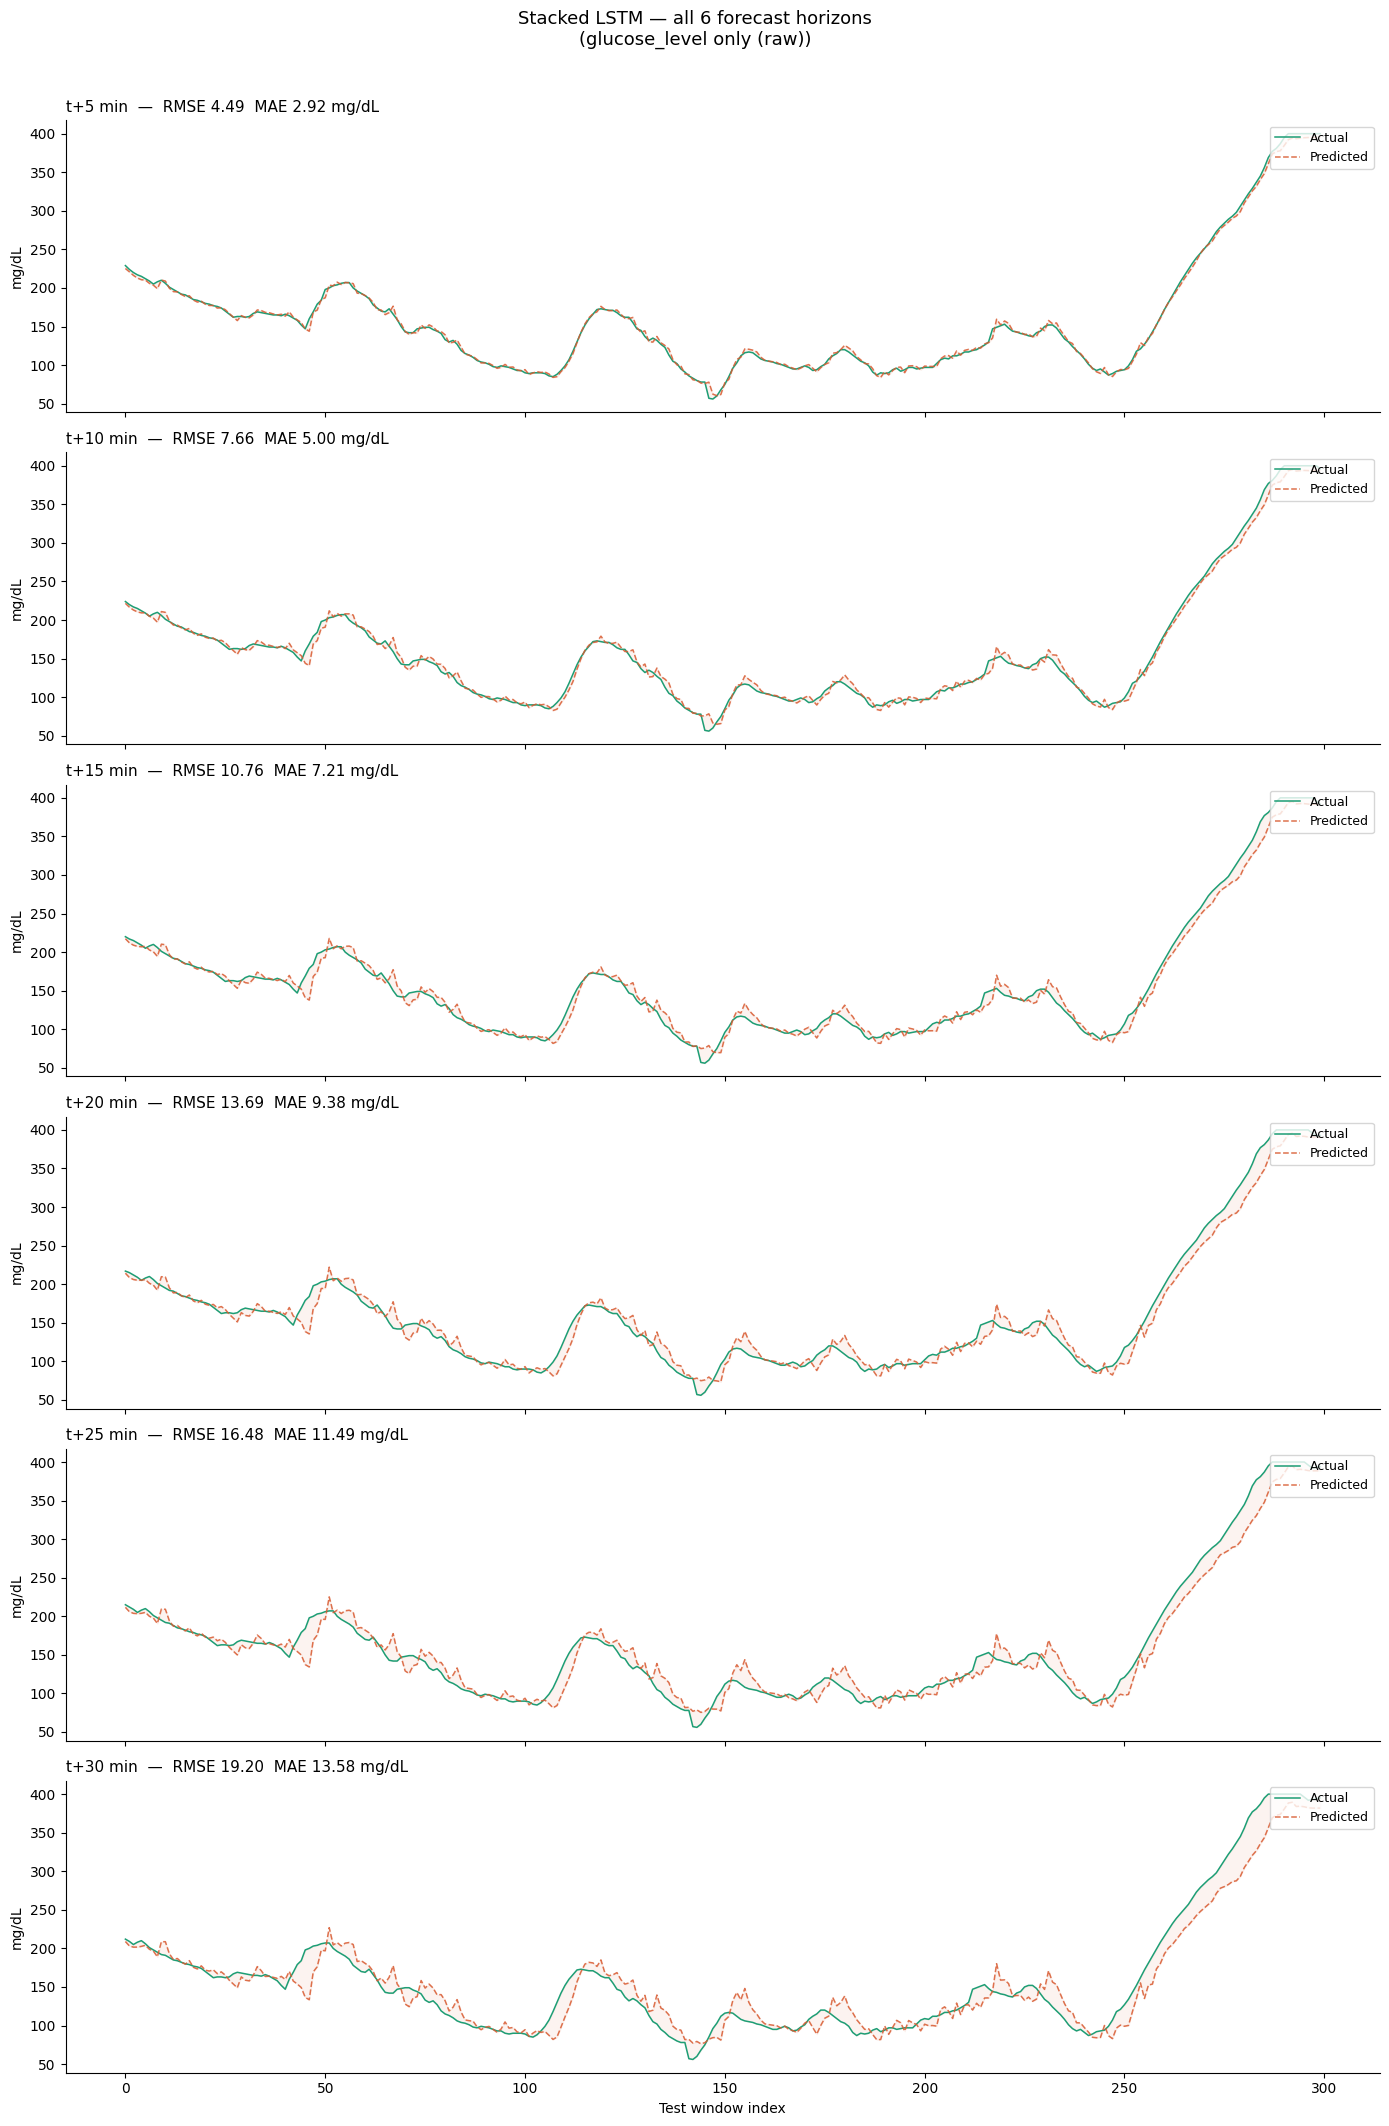

Saved: /content/drive/MyDrive/stacked_lstm_outputs12345/forecast_all_horizons.png


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

FREQ = CFG["freq_minutes"]
FORECAST_STEPS = CFG["forecast_minutes"] // FREQ  # 6
N_PLOT = 300

tag_slug = variants[0]["tag"].lower().replace(" ", "_").replace("+", "plus")
pred_path = OUTPUT_DIR / f"predictions_{tag_slug}.csv"
df = pd.read_csv(pred_path)

fig, axes = plt.subplots(FORECAST_STEPS, 1,
                          figsize=(14, 3.5 * FORECAST_STEPS),
                          sharex=True)

for step, ax in enumerate(axes, start=1):
    mins = step * FREQ
    actual = df[f"actual_t+{mins}min"].values
    preds  = df[f"predicted_t+{mins}min"].values
    n      = min(N_PLOT, len(actual))

    rmse_val = float(np.sqrt(mean_squared_error(actual, preds)))
    mae_val  = float(mean_absolute_error(actual, preds))

    ax.plot(actual[:n], label="Actual",    color="#1d9e75", linewidth=1.1)
    ax.plot(preds[:n],  label="Predicted", color="#d85a30",
            linewidth=1.1, linestyle="--", alpha=0.85)
    ax.fill_between(range(n), actual[:n], preds[:n],
                    alpha=0.07, color="#d85a30")

    ax.set_title(f"t+{mins} min  —  RMSE {rmse_val:.2f}  MAE {mae_val:.2f} mg/dL",
                 fontsize=11, loc="left")
    ax.set_ylabel("mg/dL")
    ax.legend(loc="upper right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Test window index")
fig.suptitle(f"Stacked LSTM — all 6 forecast horizons\n"
             f"({variants[0]['tag']})", fontsize=13, y=1.01)
plt.tight_layout()
save_path = OUTPUT_DIR / "forecast_all_horizons.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", save_path)

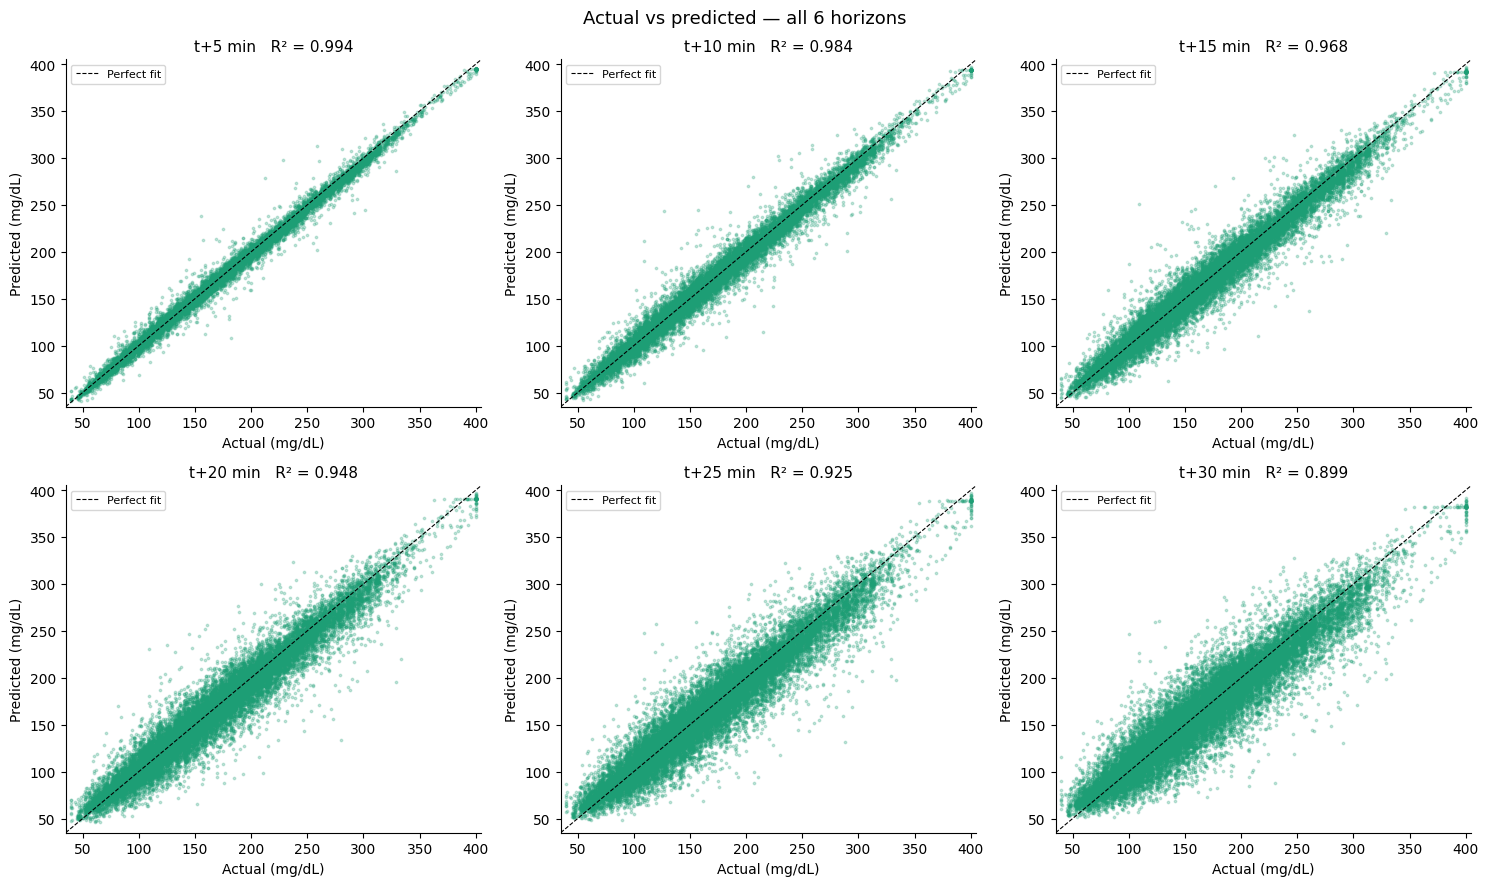

Saved: /content/drive/MyDrive/stacked_lstm_outputs12345/scatter_all_horizons.png


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import r2_score

FREQ = CFG["freq_minutes"]
FORECAST_STEPS = CFG["forecast_minutes"] // FREQ  # 6

tag_slug = variants[0]["tag"].lower().replace(" ", "_").replace("+", "plus")
df = pd.read_csv(OUTPUT_DIR / f"predictions_{tag_slug}.csv")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for step, ax in enumerate(axes, start=1):
    mins   = step * FREQ
    actual = df[f"actual_t+{mins}min"].values
    preds  = df[f"predicted_t+{mins}min"].values
    r2     = r2_score(actual, preds)

    ax.scatter(actual, preds, s=3, alpha=0.25, color="#1d9e75")
    lim = [min(actual.min(), preds.min()) - 5,
           max(actual.max(), preds.max()) + 5]
    ax.plot(lim, lim, "k--", linewidth=0.8, label="Perfect fit")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f"t+{mins} min   R² = {r2:.3f}", fontsize=11)
    ax.set_xlabel("Actual (mg/dL)")
    ax.set_ylabel("Predicted (mg/dL)")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Actual vs predicted — all 6 horizons", fontsize=13)
plt.tight_layout()
save_path = OUTPUT_DIR / "scatter_all_horizons.png"
plt.savefig(save_path, dpi=150)
plt.show()
print("Saved:", save_path)